In [14]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# 1. Chargement et Normalisation
transform = transforms.Compose([
    transforms.ToTensor(), # Convertit en [0, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 2. Fonction de bruitage
# On augmente le bruit pour rendre les images plus difficiles à identifier
def add_gaussian_noise(tensor, noise_factor=1.0):
    # torch.randn_like génère un bruit de moyenne 0 et écart-type 1
    noisy_tensor = tensor + noise_factor * torch.randn_like(tensor)
    # On restreint les valeurs entre 0 et 1 pour rester cohérent avec MNIST
    return torch.clamp(noisy_tensor, 0., 1.)

# 3. Données propres et bruitées
clean_train = train_dataset.data.unsqueeze(1).float() / 255.0
clean_test = test_dataset.data.unsqueeze(1).float() / 255.0
noisy_train = add_gaussian_noise(clean_train, noise_factor=1.5)
noisy_test = add_gaussian_noise(clean_test, noise_factor=1.5)

clean_train: torch.Size([60000, 1, 28, 28]) noisy_train: torch.Size([60000, 1, 28, 28])
Valeurs clean: 0.0 1.0
Valeurs noisy: 0.0 1.0


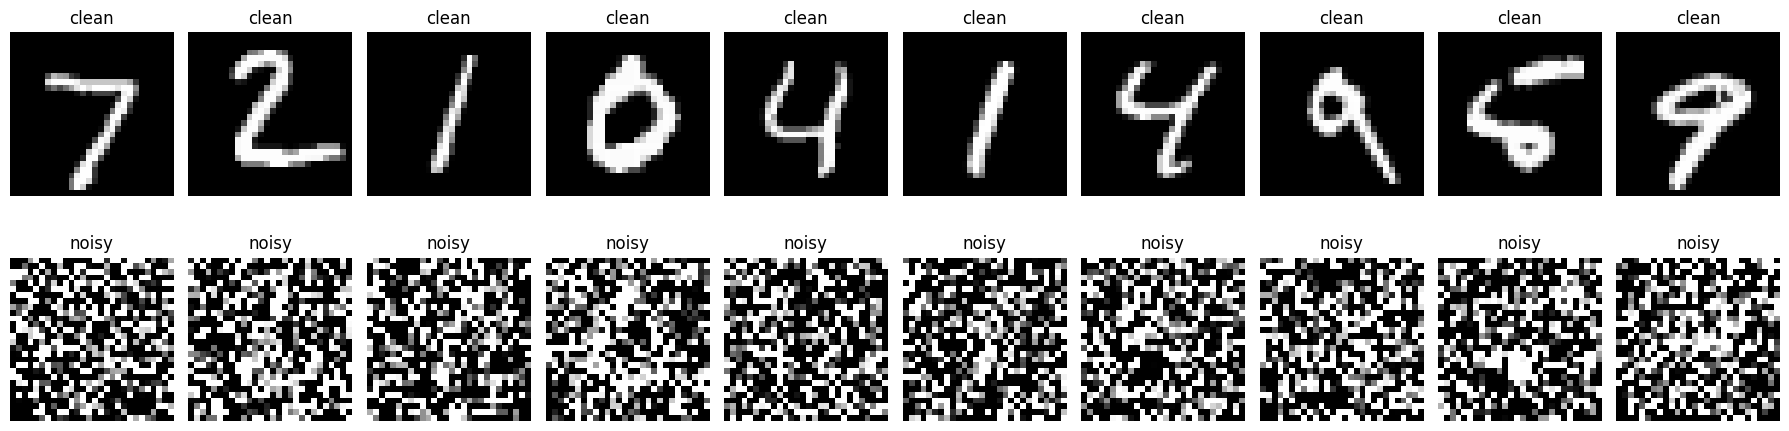

In [ ]:
print('clean_train:', clean_train.shape, 'noisy_train:', noisy_train.shape)
print('Valeurs clean:', clean_train.min().item(), clean_train.max().item())
print('Valeurs noisy:', noisy_train.min().item(), noisy_train.max().item())

fig, axes = plt.subplots(2, 10, figsize=(18, 5))
for i in range(10):
    axes[0, i].imshow(clean_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('clean')
    axes[1, i].imshow(noisy_test[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('noisy')

plt.tight_layout()
plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encodeur
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # [batch, 16, 14, 14]
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # [batch, 32, 7, 7]
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7)                       # [batch, 64, 1, 1]
        )
        # Décodeur
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=7),             # [batch, 32, 7, 7]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # [batch, 16, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # [batch, 1, 28, 28]
            nn.Sigmoid()  # valeurs entre 0 et 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [11]:
train_noisy_loader = DataLoader(torch.utils.data.TensorDataset(noisy_train, clean_train), batch_size=64, shuffle=True)
test_noisy_loader = DataLoader(torch.utils.data.TensorDataset(noisy_test, clean_test), batch_size=64, shuffle=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Epoch [1/10], Loss: 0.0399
Epoch [2/10], Loss: 0.0397
Epoch [3/10], Loss: 0.0394
Epoch [4/10], Loss: 0.0392
Epoch [5/10], Loss: 0.0390
Epoch [6/10], Loss: 0.0388
Epoch [7/10], Loss: 0.0387
Epoch [8/10], Loss: 0.0385
Epoch [9/10], Loss: 0.0384
Epoch [10/10], Loss: 0.0382


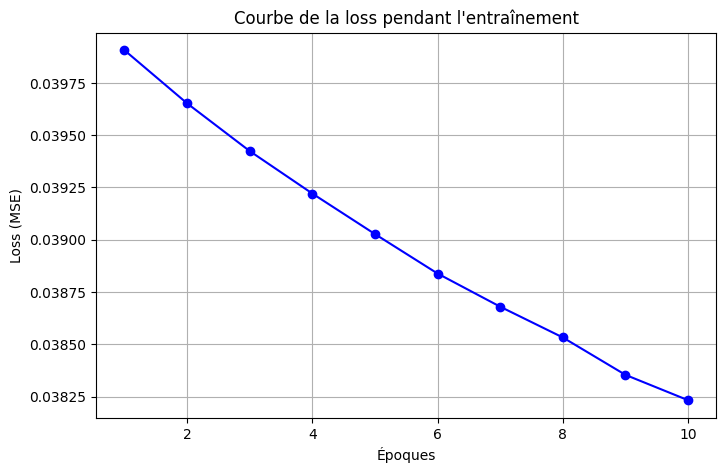

In [15]:
# On stocke les pertes à chaque époque
losses = []
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for noisy_imgs, clean_imgs in train_noisy_loader:
        noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)

        # Forward
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_noisy_loader)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Tracé de la courbe
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), losses, marker='o', color='blue')
plt.title("Courbe de la loss pendant l'entraînement")
plt.xlabel("Époques")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()



Test Loss: 0.0428


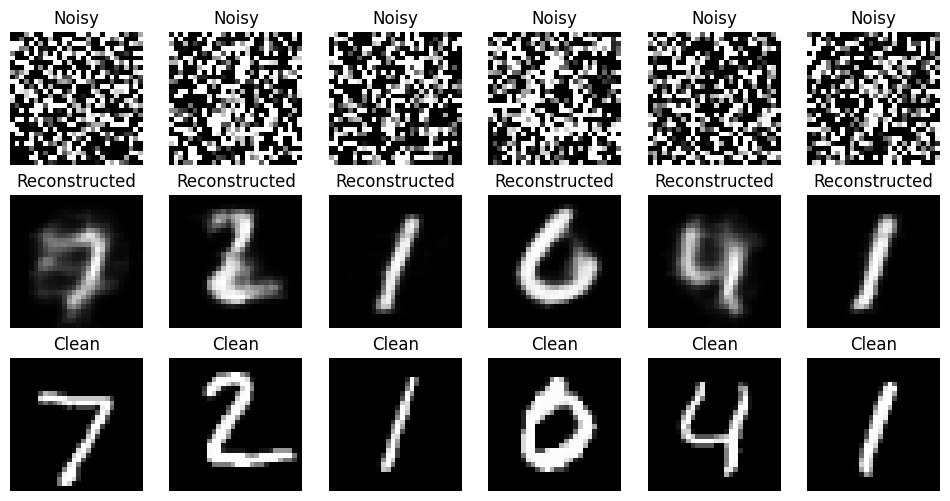

In [ ]:
# Évaluation sur le test set
test_loss = 0
model.eval()
with torch.no_grad():
    for noisy_imgs, clean_imgs in test_noisy_loader:
        noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        test_loss += loss.item()

print(f"Test Loss: {test_loss/len(test_noisy_loader):.4f}")

# 10. Visualisation des résultats
with torch.no_grad():
    noisy_imgs, clean_imgs = next(iter(test_noisy_loader))
    noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)
    outputs = model(noisy_imgs)

n = 6
plt.figure(figsize=(12,6))
for i in range(n):
    # image brutee
    plt.subplot(3, n, i+1)
    plt.imshow(noisy_imgs[i].cpu().squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")
    # image reconstruite
    plt.subplot(3, n, i+1+n)
    plt.imshow(outputs[i].cpu().squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")
    # image propre
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(clean_imgs[i].cpu().squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.show()